# Q5

## 1. Imports & Parameters

In [ ]:
import math, random, statistics, numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from PIL import Image
from IPython.display import clear_output
random.seed(7); np.random.seed(7)

IMAGE_PATH = 'lion.jpg'
ROWS, COLS = 5, 5 

PROFILE_LEN = 40
EDGE_PROFILE_DOWNSAMPLE = PROFILE_LEN

POP_SIZE = 500
GENERATIONS = 500 
TOURNAMENT_K = 5
ELITE = 4
CROSSOVER_RATE = 0.9
MUTATION_RATE = 0.35
ROTATION_RATE = 0.18

ALPHA_COLOR = 0.015
BETA_PROFILE = 1.0

SHOW_EVERY = 1

## 2. Load & Slice Image

In [20]:
@dataclass
class Piece:
    pid: int
    image: np.ndarray

def load_image(path):
    img = Image.open(path).convert('RGB')
    return np.asarray(img, dtype=np.float32)

def slice_into_pieces(img, rows, cols):
    H, W, _ = img.shape
    ph, pw = H // rows, W // cols
    pieces = []
    pid = 0
    for r in range(rows):
        for c in range(cols):
            patch = img[r*ph:(r+1)*ph, c*pw:(c+1)*pw].copy()
            pieces.append(Piece(pid, patch))
            pid += 1
    return pieces

original_img = load_image(IMAGE_PATH)
pieces = slice_into_pieces(original_img, ROWS, COLS)
N = len(pieces)
ph, pw, _ = pieces[0].image.shape

 
ORIENTATIONS = [0,1,2,3] if ph == pw else [0]  # 0,90,180,270
ORIENT_COUNT = len(ORIENTATIONS)
print(f'Pieces: {N}, piece size: {ph}x{pw}, allowed rotations: {ORIENTATIONS}')

Pieces: 25, piece size: 261x147, allowed rotations: [0]


## 3. Edge Descriptors

In [21]:
def extract_edge_pixels(arr, side):
    if side == 0: edge = arr[0, :, :]
    elif side == 1: edge = arr[:, -1, :]
    elif side == 2: edge = arr[-1, :, :]
    else: edge = arr[:, 0, :]
    return edge.reshape(-1,3)

def downsample_profile(edge_pixels, target_len):
    L = edge_pixels.shape[0]
    idx = np.linspace(0, L-1, target_len).astype(int)
    prof = edge_pixels[idx]
    prof = prof - prof.mean(axis=0, keepdims=True)
    prof = prof.flatten()
    norm = np.linalg.norm(prof) + 1e-9
    return prof / norm

def edge_descriptor(image_arr, side):
    edge = extract_edge_pixels(image_arr, side)
    mean_col = edge.mean(axis=0)
    profile = downsample_profile(edge, EDGE_PROFILE_DOWNSAMPLE)
    return {'mean': mean_col, 'profile': profile}

descriptors = [[None]*ORIENT_COUNT for _ in range(N)]

for p in pieces:
    for oi, k in enumerate(ORIENTATIONS):
        rotated = np.rot90(p.image, k=k)
        desc_list = [edge_descriptor(rotated, side) for side in range(4)]
        descriptors[p.pid][oi] = desc_list


Descriptor precompute done.


## 4. Edge Fit

In [ ]:
def edge_fit_score(pid_a, ori_idx_a, edge_a, pid_b, ori_idx_b, edge_b):
    da = descriptors[pid_a][ori_idx_a][edge_a]
    db = descriptors[pid_b][ori_idx_b][edge_b]
    color_dist = np.linalg.norm(da['mean'] - db['mean'])
    color_term = math.exp(-ALPHA_COLOR * color_dist)
    sim = float(np.dot(da['profile'], db['profile'])) 
    profile_term = (sim + 1.0)/2.0
    return color_term + BETA_PROFILE * profile_term

## 5. Individual & Fitness

In [23]:
def evaluate(perm, orient):
    total = 0.0
    for r in range(ROWS):
        for c in range(COLS):
            idx = r*COLS + c
            pid = perm[idx]
            ori_idx = orient[pid]
            if c < COLS-1:
                pid_r = perm[idx+1]; ori_r = orient[pid_r]
                total += edge_fit_score(pid, ori_idx, 1, pid_r, ori_r, 3)
            if r < ROWS-1:
                pid_b = perm[idx+COLS]; ori_b = orient[pid_b]
                total += edge_fit_score(pid, ori_idx, 2, pid_b, ori_b, 0)
    return total

def make_individual():
    perm = list(range(N)); random.shuffle(perm)
    orient = [random.randrange(ORIENT_COUNT) for _ in range(N)]
    return perm, orient

## 6. Selection, Crossover, Mutation

In [24]:
def tournament(pop, k=TOURNAMENT_K):
    return max(random.sample(pop, k), key=lambda x: x['fitness'])

def order_crossover(a, b):
    pa, oa = a['perm'], a['orient']
    pb, ob = b['perm'], b['orient']
    n = len(pa)
    i, j = sorted(random.sample(range(n),2))
    child = [None]*n
    child[i:j] = pa[i:j]
    rest = [x for x in pb if x not in child[i:j]]
    ptr = 0
    for idx in range(n):
        if child[idx] is None:
            child[idx] = rest[ptr]; ptr += 1
    seg = set(pa[i:j])
    child_orient = [oa[pid] if pid in seg else ob[pid] for pid in range(n)]
    return child, child_orient

def mutate(perm, orient):
    n = len(perm)
    if random.random() < MUTATION_RATE:
        a,b = random.sample(range(n),2); perm[a], perm[b] = perm[b], perm[a]
    if random.random() < MUTATION_RATE:
        w = random.randint(2, min(6,n)); s = random.randint(0, n-w)
        seg = perm[s:s+w]; random.shuffle(seg); perm[s:s+w] = seg
    if ORIENT_COUNT > 1:
        for pid in range(n):
            if random.random() < ROTATION_RATE:
                choices = [i for i in range(ORIENT_COUNT) if i != orient[pid]]
                orient[pid] = random.choice(choices)
    return perm, orient

## 7. Reconstruction Helper

In [25]:
def reconstruct_image(solution):
    perm = solution['perm']; orient = solution['orient']
    canvas = np.zeros((ph*ROWS, pw*COLS, 3), dtype=np.float32)
    for r in range(ROWS):
        for c in range(COLS):
            idx = r*COLS + c
            pid = perm[idx]
            k = ORIENTATIONS[orient[pid]]
            img_piece = np.rot90(pieces[pid].image, k=k)
            canvas[r*ph:(r+1)*ph, c*pw:(c+1)*pw] = img_piece
    return canvas.astype(np.uint8)

## 8. GA Loop (With Per-Generation Display)

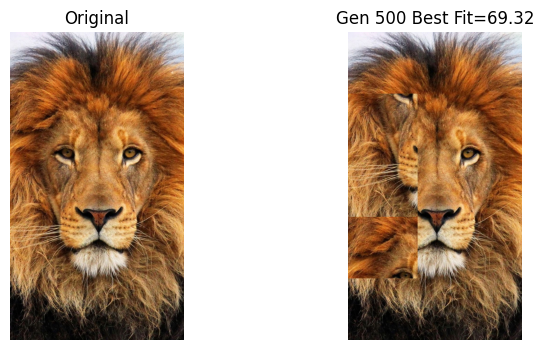

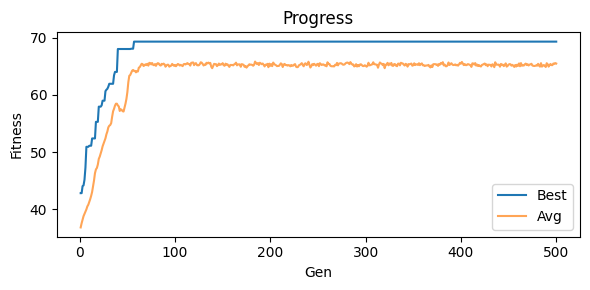

Final best fitness: 69.31622029085004


In [26]:
def build_population():
    pop = []
    for _ in range(POP_SIZE):
        perm, orient = make_individual()
        fit = evaluate(perm, orient)
        pop.append({'perm': perm, 'orient': orient, 'fitness': fit})
    return pop

history = []

def evolve():
    pop = build_population()
    best = max(pop, key=lambda x: x['fitness'])
    for gen in range(1, GENERATIONS+1):
        new_pop = []
        elites = sorted(pop, key=lambda x: -x['fitness'])[:ELITE]
        new_pop.extend(elites)
        while len(new_pop) < POP_SIZE:
            p1 = tournament(pop); p2 = tournament(pop)
            if random.random() < CROSSOVER_RATE:
                child_perm, child_orient = order_crossover(p1, p2)
            else:
                child_perm = p1['perm'][:]; child_orient = p1['orient'][:]
            child_perm, child_orient = mutate(child_perm, child_orient)
            fit = evaluate(child_perm, child_orient)
            new_pop.append({'perm': child_perm, 'orient': child_orient, 'fitness': fit})
        pop = new_pop
        current_best = max(pop, key=lambda x: x['fitness'])
        if current_best['fitness'] > best['fitness']:
            best = current_best
        avg = statistics.mean(p['fitness'] for p in pop)
        history.append({'gen': gen, 'best': best['fitness'], 'avg': avg})
        if gen % SHOW_EVERY == 0:
            clear_output(wait=True)
            assembled = reconstruct_image(best)
            plt.figure(figsize=(8,4))
            plt.subplot(1,2,1); plt.imshow(original_img.astype(np.uint8)); plt.title('Original'); plt.axis('off')
            plt.subplot(1,2,2); plt.imshow(assembled); plt.title(f'Gen {gen} Best Fit={best['fitness']:.2f}'); plt.axis('off')
            plt.show()
            
            gens = [h['gen'] for h in history]
            bvals = [h['best'] for h in history]
            avals = [h['avg'] for h in history]
            plt.figure(figsize=(6,3))
            plt.plot(gens, bvals, label='Best')
            plt.plot(gens, avals, label='Avg', alpha=0.7)
            plt.xlabel('Gen'); plt.ylabel('Fitness'); plt.title('Progress'); plt.legend(); plt.tight_layout(); plt.show()
    return best

best_solution = evolve()
print('Final best fitness:', best_solution['fitness'])

## 9. Final Arrangement Summary

In [27]:
for r in range(ROWS):
    row = best_solution['perm'][r*COLS:(r+1)*COLS]
    print(' '.join(f'{x:02d}' for x in row))
print('Orient index per piece id (maps to ORIENTATIONS list):')
print({pid: best_solution['orient'][pid] for pid in range(N)})

00 01 02 03 04
10 11 07 08 09
15 16 12 13 14
05 06 17 18 19
20 21 22 23 24
Orient index per piece id (maps to ORIENTATIONS list):
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0}


# Q12

GD fixed: iters = 32076 f(x) = 1.2517236785593725e-12 ||grad|| = 9.998902159838967e-07
GD backtracking: iters = 2000 f(x) = 0.00012927530765325526 ||grad|| = 0.015386050788658609
Newton: iters = 6 f(x) = 3.4326461875363225e-20 ||grad|| = 8.285705791275366e-09


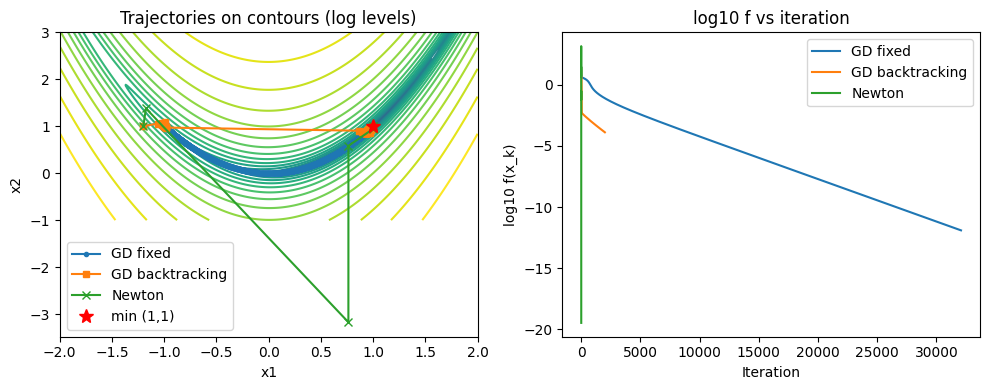


Summary:
GD fixed (alpha=0.001): final f = 1.2517236785593725e-12 iters = 32076
GD backtracking: final f = 0.00012927530765325526 iters = 2000
Newton (full step): final f = 3.4326461875363225e-20 iters = 6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def f(x):
    x1, x2 = x[0], x[1]
    return 100.0*(x2 - x1**2)**2 + (1.0 - x1)**2

def grad(x):
    x1, x2 = x[0], x[1]
    g1 = -400.0*x1*(x2 - x1**2) - 2.0*(1.0 - x1)
    g2 = 200.0*(x2 - x1**2)
    return np.array([g1, g2])

def hess(x):
    x1, x2 = x[0], x[1]
    H11 = 1200.0*x1**2 - 400.0*x2 + 2.0  
    H12 = -400.0*x1
    H22 = 200.0
    return np.array([[H11, H12],[H12, H22]])


def gradient_descent(x0, alpha=0.001, max_iters=5000, tol=1e-6):
    x = x0.copy().astype(float)
    xs = [x.copy()]
    fs = [f(x)]
    grads = [np.linalg.norm(grad(x))]
    for k in range(max_iters):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - alpha * g
        xs.append(x.copy())
        fs.append(f(x))
        grads.append(np.linalg.norm(grad(x)))
    return np.array(xs), np.array(fs), np.array(grads)


def backtracking_ls(x, p, alpha0=1.0, rho=0.5, c=1e-4):
    alpha = alpha0
    fx = f(x)
    gx = grad(x)
    while f(x + alpha * p) > fx + c * alpha * gx.dot(p):
        alpha *= rho
    return alpha


def newton(x0, max_iters=200, tol=1e-6):
    x = x0.copy().astype(float)
    xs = [x.copy()]
    fs = [f(x)]
    grads = [np.linalg.norm(grad(x))]
    for k in range(max_iters):
        g = grad(x)
        ng = np.linalg.norm(g)
        if ng < tol:
            break
        H = hess(x)
        try:
            p = np.linalg.solve(H, -g) 
        except np.linalg.LinAlgError:
            print('Hessian singular at iter', k)
            break
        x = x + p  
        xs.append(x.copy())
        fs.append(f(x))
        grads.append(np.linalg.norm(grad(x)))
    return np.array(xs), np.array(fs), np.array(grads)


x0 = np.array([-1.2, 1.0])


xs_gd, fs_gd, grads_gd = gradient_descent(x0, alpha=0.001, max_iters=50000, tol=1e-6)


def gd_backtracking(x0, max_iters=2000, tol=1e-6):
    x = x0.copy().astype(float)
    xs = [x.copy()]
    fs = [f(x)]
    grads = [np.linalg.norm(grad(x))]
    for k in range(max_iters):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        p = -g
        alpha = backtracking_ls(x, p, alpha0=1.0, rho=0.5, c=1e-4)
        x = x + alpha * p
        xs.append(x.copy())
        fs.append(f(x))
        grads.append(np.linalg.norm(grad(x)))
    return np.array(xs), np.array(fs), np.array(grads)

xs_gd_bt, fs_gd_bt, grads_gd_bt = gd_backtracking(x0, max_iters=2000, tol=1e-6)


xs_nt, fs_nt, grads_nt = newton(x0, max_iters=200, tol=1e-6)


print('GD fixed: iters =', len(fs_gd)-1, 'f(x) =', fs_gd[-1], '||grad|| =', grads_gd[-1])
print('GD backtracking: iters =', len(fs_gd_bt)-1, 'f(x) =', fs_gd_bt[-1], '||grad|| =', grads_gd_bt[-1])
print('Newton: iters =', len(fs_nt)-1, 'f(x) =', fs_nt[-1], '||grad|| =', grads_nt[-1])

x1s = np.linspace(-2, 2, 400)
x2s = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1s, x2s)
Z = 100.0*(X2 - X1**2)**2 + (1.0 - X1)**2

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
levels = np.logspace(-3, 3, 25)
plt.contour(X1, X2, Z, levels=levels, norm=LogNorm(), cmap='viridis')
plt.plot(xs_gd[:,0], xs_gd[:,1], 'o-', markersize=3, label='GD fixed')
plt.plot(xs_gd_bt[:,0], xs_gd_bt[:,1], 's-', markersize=4, label='GD backtracking')
plt.plot(xs_nt[:,0], xs_nt[:,1], 'x-', markersize=6, label='Newton')
plt.plot(1,1,'r*',markersize=10,label='min (1,1)')
plt.legend()
plt.title('Trajectories on contours (log levels)')
plt.xlabel('x1')
plt.ylabel('x2')

plt.subplot(1,2,2)
plt.plot(np.log10(fs_gd + 1e-30), label='GD fixed')
plt.plot(np.log10(fs_gd_bt + 1e-30), label='GD backtracking')
plt.plot(np.log10(fs_nt + 1e-30), label='Newton')
plt.xlabel('Iteration')
plt.ylabel('log10 f(x_k)')
plt.legend()
plt.title('log10 f vs iteration')
plt.tight_layout()
plt.show()


print('\nSummary:')
print('GD fixed (alpha=0.001): final f =', fs_gd[-1], 'iters =', len(fs_gd)-1)
print('GD backtracking: final f =', fs_gd_bt[-1], 'iters =', len(fs_gd_bt)-1)
print('Newton (full step): final f =', fs_nt[-1], 'iters =', len(fs_nt)-1)

# Q14

Armijo GD: iterations = 2000 final f = 0.00012927530765325526
AdaGrad GD: iterations = 20000 final f = 5.593684817319085e-15


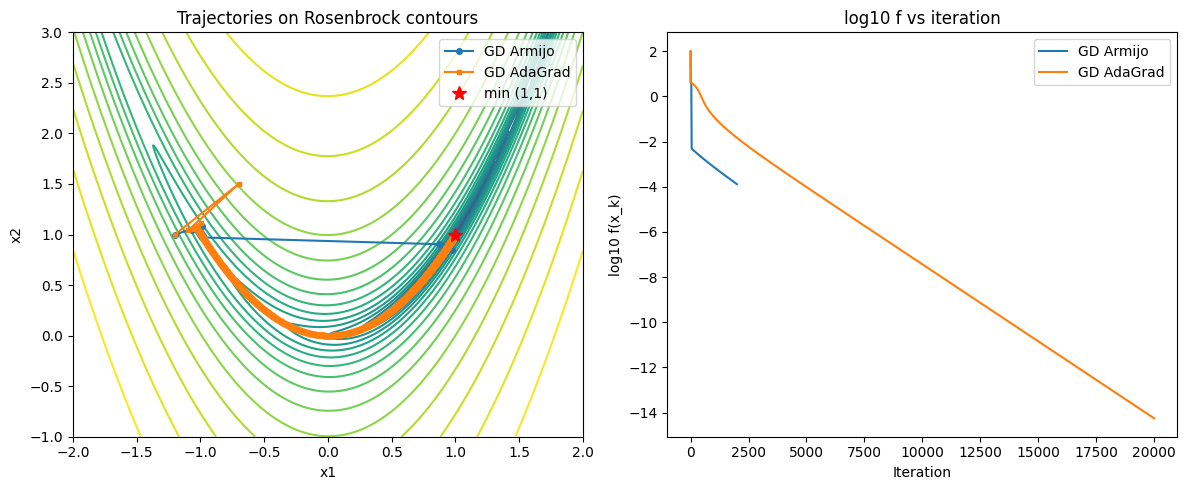


Final positions:
Armijo final x = [0.98865264 0.97736244] f = 0.00012927530765325526
AdaGrad final x = [0.99999993 0.99999985] f = 5.593684817319085e-15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def f(x):
    x1, x2 = x[0], x[1]
    return 100.0*(x2 - x1**2)**2 + (1.0 - x1)**2

def grad(x):
    x1, x2 = x[0], x[1]
    g1 = -400.0*x1*(x2 - x1**2) - 2.0*(1.0 - x1)
    g2 = 200.0*(x2 - x1**2)
    return np.array([g1, g2])


def backtracking_armijo(x, p, alpha0=1.0, rho=0.5, c=1e-4, max_iters=50):
    alpha = alpha0
    fx = f(x)
    gx = grad(x)
    for i in range(max_iters):
        if f(x + alpha * p) <= fx + c * alpha * gx.dot(p):
            return alpha
        alpha *= rho
    return alpha


def gd_armijo(x0, max_iters=2000, tol=1e-8):
    x = x0.copy().astype(float)
    xs = [x.copy()]
    fs = [f(x)]
    grads = [np.linalg.norm(grad(x))]
    for k in range(max_iters):
        g = grad(x)
        ng = np.linalg.norm(g)
        if ng < tol:
            break
        p = -g
        alpha = backtracking_armijo(x, p, alpha0=1.0, rho=0.5, c=1e-4)
        x = x + alpha * p
        xs.append(x.copy())
        fs.append(f(x))
        grads.append(np.linalg.norm(grad(x)))
    return np.array(xs), np.array(fs), np.array(grads)


def gd_adagrad(x0, eta=0.1, eps=1e-8, max_iters=20000, tol=1e-8):
    x = x0.copy().astype(float)
    xs = [x.copy()]
    fs = [f(x)]
    grads = [np.linalg.norm(grad(x))]
    s = np.zeros_like(x)
    for k in range(max_iters):
        g = grad(x)
        ng = np.linalg.norm(g)
        if ng < tol:
            break
        s += g*g
        adj = eta / (np.sqrt(s) + eps)
        x = x - adj * g
        xs.append(x.copy())
        fs.append(f(x))
        grads.append(np.linalg.norm(grad(x)))
    return np.array(xs), np.array(fs), np.array(grads)

x0 = np.array([-1.2, 1.0])

xs_armijo, fs_armijo, grads_armijo = gd_armijo(x0, max_iters=2000, tol=1e-8)
xs_adagrad, fs_adagrad, grads_adagrad = gd_adagrad(x0, eta=0.5, eps=1e-8, max_iters=20000, tol=1e-8)

print('Armijo GD: iterations =', len(fs_armijo)-1, 'final f =', fs_armijo[-1])
print('AdaGrad GD: iterations =', len(fs_adagrad)-1, 'final f =', fs_adagrad[-1])

x1s = np.linspace(-2, 2, 400)
x2s = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1s, x2s)
Z = 100.0*(X2 - X1**2)**2 + (1.0 - X1)**2

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
levels = np.logspace(-3, 3, 25)
plt.contour(X1, X2, Z, levels=levels, norm=LogNorm(), cmap='viridis')
plt.plot(xs_armijo[:,0], xs_armijo[:,1], 'o-', markersize=4, label='GD Armijo')
plt.plot(xs_adagrad[:,0], xs_adagrad[:,1], 's-', markersize=3, label='GD AdaGrad')
plt.plot(1,1,'r*',markersize=10,label='min (1,1)')
plt.legend()
plt.title('Trajectories on Rosenbrock contours')
plt.xlabel('x1')
plt.ylabel('x2')

plt.subplot(1,2,2)
plt.plot(np.log10(fs_armijo + 1e-30), label='GD Armijo')
plt.plot(np.log10(fs_adagrad + 1e-30), label='GD AdaGrad')
plt.xlabel('Iteration')
plt.ylabel('log10 f(x_k)')
plt.legend()
plt.title('log10 f vs iteration')
plt.tight_layout()
plt.show()

print('\nFinal positions:')
print('Armijo final x =', xs_armijo[-1], 'f =', fs_armijo[-1])
print('AdaGrad final x =', xs_adagrad[-1], 'f =', fs_adagrad[-1])